In [1]:
#import statements
import os
os.chdir("..")
from pathlib import Path
from typing import List, Dict, Optional, Union
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm import tqdm
from diffusers import AutoPipelineForText2Image, LCMScheduler

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## K-Steering Class

In [2]:
#Here's the classifier 
class K_Steering:
    def __init__(self, input_dim, num_classes=6, hidden_dim=256, lr=1e-3, device='cuda'):
        """
        Parameters:
          - input_dim: dimensionality of your raw activations.
          - num_classes: number of tone classes to classify.
          - hidden_dim: size of the hidden layer in the MLP.
          - lr: learning rate for training the classifier.
          - device: 'cuda' or 'cpu'.
        """
        self.device = device
        self.num_classes = num_classes
        
        # Define a multi-class MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)  # outputs logits for each tone class
        ).to(device)
        
        self.optimizer = optim.Adam(self.classifier.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Store class names for reference
        self.class_names = None
        

    def fit(self, activations_dict, epochs=30, batch_size=32, class_weights=None, val_split=0.2):
        """
        Train the multiclass classifier on raw activations.

        Parameters:
          - activations_dict: Dictionary mapping class names to NumPy arrays of activations.
          - epochs: number of training epochs.
          - batch_size: training batch size.
          - class_weights: Optional tensor of weights for each class to handle imbalance.
          - val_split: Fraction of data to use for validation (default: 0.2)
        """
        self.class_names = list(activations_dict.keys())
        assert len(self.class_names) == self.num_classes, f"Expected {self.num_classes} classes, got {len(self.class_names)}"
        
        # Prepare data and split train/val
        X_list = []
        y_list = []
        
        for i, class_name in enumerate(self.class_names):
            X_class = torch.tensor(activations_dict[class_name], dtype=torch.float32, device=self.device)
            y_class = torch.full((X_class.size(0),), i, dtype=torch.long, device=self.device)
            X_list.append(X_class)
            y_list.append(y_class)
        
        X = torch.cat(X_list, dim=0)
        y = torch.cat(y_list, dim=0)
        
        # Split train/val
        n_total = X.size(0)
        n_val = int(n_total * val_split)
        indices = torch.randperm(n_total)
        train_idx, val_idx = indices[n_val:], indices[:n_val]
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
        
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
        
        # Set class weights for loss function if provided
        if class_weights is not None:
            self.loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(self.device))
        else:
            self.loss_fn = nn.CrossEntropyLoss()
        
        # Train the classifier
        for epoch in range(epochs):
            self.classifier.train()
            epoch_loss = 0.0
            train_correct = 0
            train_total = 0
            
            for batch_X, batch_y in train_loader:
                self.optimizer.zero_grad()
                logits = self.classifier(batch_X)  # shape: (batch, num_classes)
                loss = self.loss_fn(logits, batch_y)
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(logits.data, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            
            # Validate
            self.classifier.eval()
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    logits = self.classifier(batch_X)
                    _, predicted = torch.max(logits.data, 1)
                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()
            
            train_acc = 100 * train_correct / train_total
            val_acc = 100 * val_correct / val_total
            avg_loss = epoch_loss / len(train_loader)
            
            print(f"Epoch {epoch}: Loss={avg_loss:.4f}, Train={train_acc:.1f}%, Val={val_acc:.1f}%")
            
        # Evaluate per-class on validation set
        self.classifier.eval()
        class_accuracies = {}
        
        with torch.no_grad():
            for i, class_name in enumerate(self.class_names):
                # Get validation samples for this class
                class_mask = y_val == i
                if class_mask.sum() == 0:
                    continue
                
                X_class_val = X_val[class_mask]
                y_class_val = y_val[class_mask]
                
                logits = self.classifier(X_class_val)
                _, predicted = torch.max(logits.data, 1)
                accuracy = 100 * (predicted == y_class_val).sum().item() / y_class_val.size(0)
                class_accuracies[class_name] = accuracy
                print(f"Val accuracy for {class_name}: {accuracy:.2f}%")

    def steer_attributes(self, activation, target=None, avoid=None, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation toward target tones and away from tones to avoid.
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - target_tones: list of tone names to steer toward.
        - avoid_tones: list of tone names to steer away from.
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """
        
        # Get indices for target and avoid tones
        target_indices = [self.class_names.index(tone) for tone in target] if target else []
        avoid_indices = [self.class_names.index(tone) for tone in avoid] if avoid else []
        
        
        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()
        return X_new_np

    def steer_attributes_unsupervised(self, activation, alpha=0.1, steps=1, decay_rate=0.95):
        """
        Steer the given activation, calculate the mean of the activations of all classes and steer away of those above the mean and towards those away from the mean .
        
        Parameters:
        - activation: a NumPy array of shape (D,) or (N, D).
        - alpha: scaling factor for the update.
        - steps: number of gradient descent steps to take.
        
        Returns:
        - The modified activation as a NumPy array.
        """


        # Convert activation to a torch tensor
        X = torch.tensor(activation, dtype=torch.float32, device=self.device)
        
        current_alpha = alpha
        
        # Perform multiple steps of gradient descent
        for step in range(steps):
            if step > 0:
                current_alpha *= decay_rate
            # Need to create a new tensor that requires gradients for each step
            X = X.detach().requires_grad_(True)
            
            # Forward pass: compute classifier output (logits)
            self.classifier.eval()
            logits = self.classifier(X)  # shape: [N, num_classes]
            
            # Create custom loss function to maximize target tone scores and minimize avoid tone scores
            loss = 0
            mean_logits = torch.mean(logits, dim=1)

            target_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() < mean_logits]
            avoid_indices = [i for i, logits in enumerate(logits) if logits[:,i].mean() > mean_logits]
            
            if target_indices:
                target_logits = logits[:, target_indices]
                # Negative because we want to maximize these logits (gradient descent will minimize)
                loss = loss - target_logits.mean()
            
            if avoid_indices:
                avoid_logits = logits[:, avoid_indices]
                # Positive because we want to minimize these logits
                loss = loss + avoid_logits.mean()
            
            # If no target or avoid tones provided, do nothing
            if not target_indices and not avoid_indices:
                return activation
            
            # Compute gradients
            loss.backward()
            
            # Get the gradient with respect to the input activation
            grad = X.grad.data
            
            # Update the activation by moving in the loss gradient direction
            # Negative gradient because we're trying to minimize the loss

            X = X - current_alpha * grad
        
        # Convert back to NumPy
        X_new_np = X.detach().cpu().numpy()

        return X_new_np

## Utils for hook function

In [3]:
#These are the data loading functions
import torch, numpy as np, matplotlib.pyplot as plt, torchvision
from sklearn.decomposition import PCA
from PIL import Image

def visualize_image(x, title=None, figsize=(5,5)):
    # → torch.FloatTensor (CPU)
    if isinstance(x, Image.Image): x = np.array(x)
    x = torch.as_tensor(x).detach().cpu().float()
    #we should normalise rgb

    # Channels-last → channels-first if needed
    def ch_last_to_first(t):
        return t.permute(2,0,1) if t.ndim==3 and t.shape[-1] in (1,3) else t

    x = ch_last_to_first(x)
    cmap = None

    if x.ndim == 4:  # [B,C,H,W]
        grid = torchvision.utils.make_grid(x, nrow=2, normalize=True, padding=2)
        img = grid.permute(1,2,0).numpy()
        #we should normalise rgb
    elif x.ndim == 3:  # [C,H,W]
        C,H,W = x.shape
        if C == 1:
            img, cmap = x.squeeze(0).numpy(), 'gray'
        elif C == 3:
            img = x.permute(1,2,0).numpy()
        else:
            pcs = PCA(n_components=3).fit_transform(x.view(C,-1).T.numpy())
            pcs = (pcs - pcs.min())/(pcs.max()-pcs.min()+1e-8)
            img = pcs.reshape(H,W,3)
    elif x.ndim == 2:  # [H,W]
        img, cmap = x.numpy(), 'gray'
    else:

        raise ValueError(f"Unsupported shape: {tuple(x.shape)}")
    #normalise rgb
    img = img / 255.0
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')
    if title: plt.title(title)
    plt.show()



def load_fairface_by_ethnicity_hf(
    hf_data,                           # e.g. load_dataset("HuggingFaceM4/FairFace", "0.25", split="train")
    categories: Optional[List[str]] = None,
    max_images: Optional[int] = None,  # per-category cap
    return_pil: bool = True,
    verbose: bool = True
) -> Dict[str, List[Union[str, Image.Image]]]:
    """
    Load FairFace (Hugging Face version) organized by racial/ethnic categories.
    Returns a dict: {category_key: [PIL.Image (or np.ndarray if return_pil=False), ...]}

    - Accepts both 'East Asian' and 'East_Asian' style names in `categories`.
    - `max_images` applies PER CATEGORY.
    - Works with standard datasets or streaming (IterableDataset).
    """

    # Discover label names (if available) to build defaults and map indices->names
    features = getattr(hf_data, "features", None)
    race_feature = features["race"] if (features and "race" in features) else None
    race_names = list(getattr(race_feature, "names", [])) if race_feature is not None else []

    # Default categories (canonical, underscore style)
    default_categories = [
        "Black", "East_Asian", "Indian", "Latino_Hispanic",
        "Middle_Eastern", "Southeast_Asian", "White"
    ]

    # Normalization helpers
    def canon_key(label: str) -> str:
        # Convert a display label (e.g., "East Asian") to canonical key with underscores
        return label.replace(" ", "_")

    def display_from_index(idx: int) -> str:
        # Turn integer class index into display label (e.g., 2 -> "Black")
        if race_names and 0 <= idx < len(race_names):
            return race_names[idx]
        return str(idx)

    def to_canonical_list(cats: Optional[List[str]]) -> List[str]:
        if cats is None:
            return default_categories
        # Accept both "East Asian" and "East_Asian"
        return [canon_key(c) for c in cats]

    categories = to_canonical_list(categories)

    # Prepare buckets
    dataset: Dict[str, List[Union[str, Image.Image]]] = {cat: [] for cat in categories}
    counts = {cat: 0 for cat in categories}

    # Helper to check if we can stop early when max_images is set
    def all_full() -> bool:
        return max_images is not None and all(counts[cat] >= max_images for cat in categories)

    # Iterate once and bucket samples
    for ex in hf_data:
        # race can be an int (class index) or a string depending on dataset config
        race_val = ex["race"]
        if isinstance(race_val, int):
            race_label = display_from_index(race_val)  # e.g., "Black"
        else:
            race_label = str(race_val)

        key = canon_key(race_label)  # e.g., "Middle_Eastern"
        if key in dataset and (max_images is None or counts[key] < max_images):
            img = ex["image"]  # Usually a PIL.Image already for HF Image feature

            # Ensure PIL or numpy as requested
            if return_pil:
                if not isinstance(img, Image.Image):
                    img = Image.fromarray(np.array(img))
                img = img.convert("RGB")
            else:
                if isinstance(img, Image.Image):
                    img = np.asarray(img.convert("RGB"))
                else:
                    img = np.asarray(img)

            dataset[key].append(img)
            counts[key] += 1

        if all_full():
            break

    if verbose:
        for cat in categories:
            print(f"{cat}: {counts[cat]} images")

    return dataset

In [4]:
# Match your original API
data = load_fairface_by_ethnicity_hf(
    load_dataset("Narmeen07/fairface-trainval-race-balanced-200", split="train"),
    #categories=["Black", "East_Asian", "White"],  # accepts space or underscore; both work                         # per category
    return_pil=True
)

Black: 200 images
East_Asian: 200 images
Indian: 200 images
Latino_Hispanic: 200 images
Middle_Eastern: 200 images
Southeast_Asian: 200 images
White: 200 images


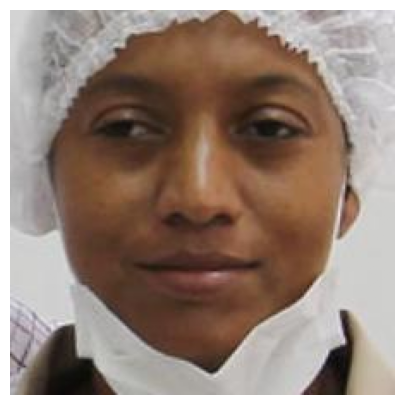

None


In [5]:
ref_image = data['Black'][0]
print(visualize_image(ref_image))

## This is how we load the model

In [6]:
from transformers.models.patchtst.modeling_patchtst import weighted_average


pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16
).to("cuda:0")
#pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

pipe.load_ip_adapter(
    pretrained_model_name_or_path_or_dict="h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter_sdxl.bin"
)


Loading pipeline components...:  57%|█████▋    | 4/7 [00:00<00:00, 14.30it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.66it/s]


## This is how we can use it for conditioned generations

conditioning image


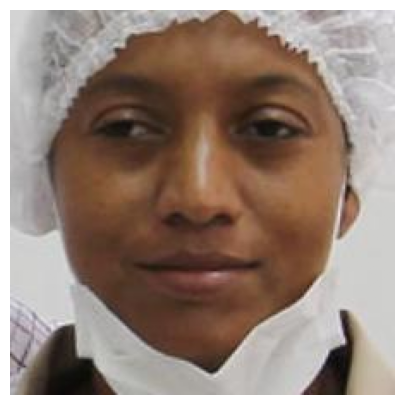

100%|██████████| 50/50 [00:05<00:00,  9.70it/s]


generated image


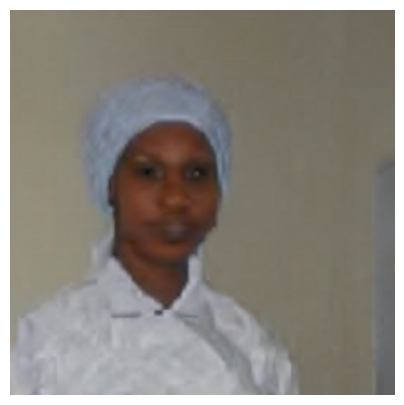

conditioning image


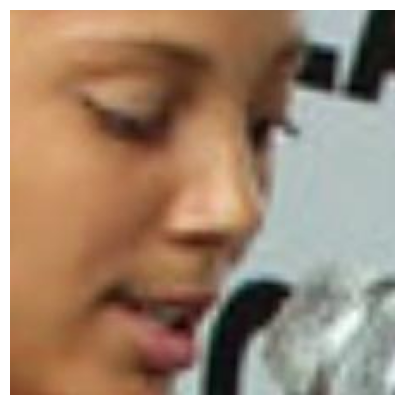

100%|██████████| 50/50 [00:05<00:00,  9.94it/s]


generated image


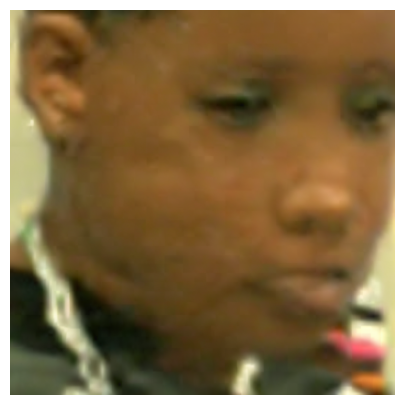

conditioning image


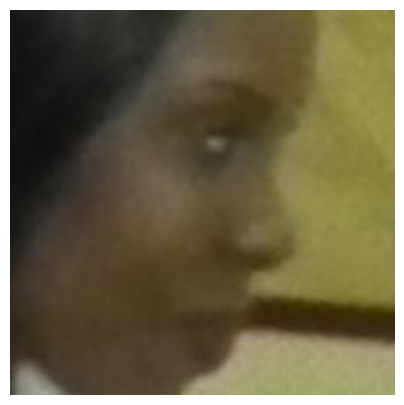

100%|██████████| 50/50 [00:05<00:00,  9.85it/s]


generated image


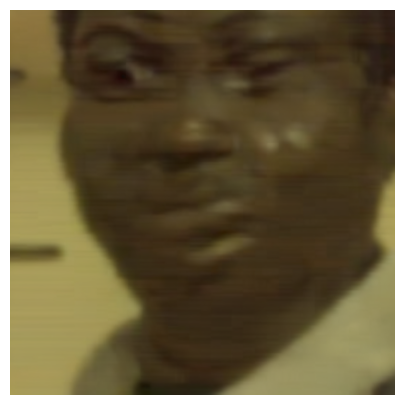

conditioning image


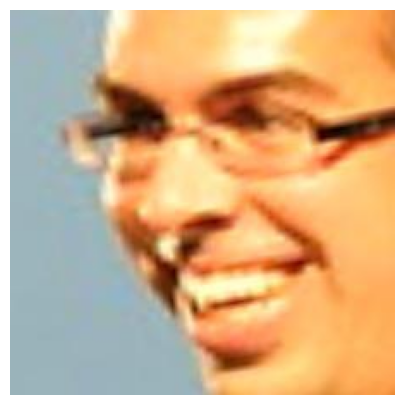

100%|██████████| 50/50 [00:05<00:00,  9.96it/s]


generated image


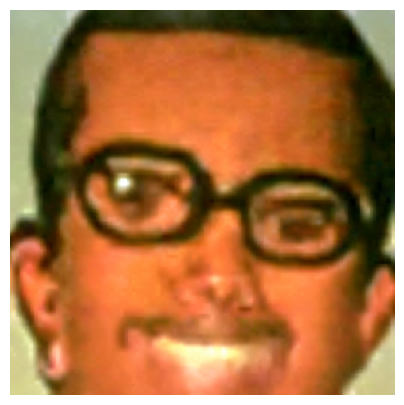

conditioning image


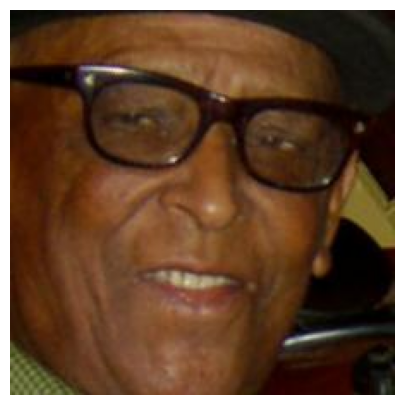

100%|██████████| 50/50 [00:05<00:00,  9.92it/s]


generated image


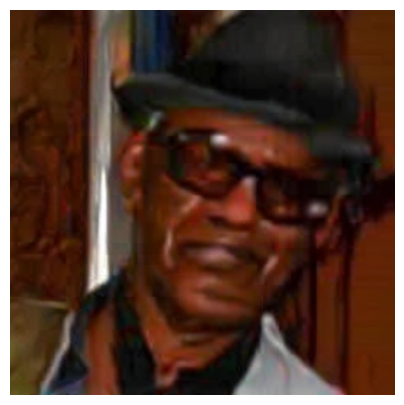

conditioning image


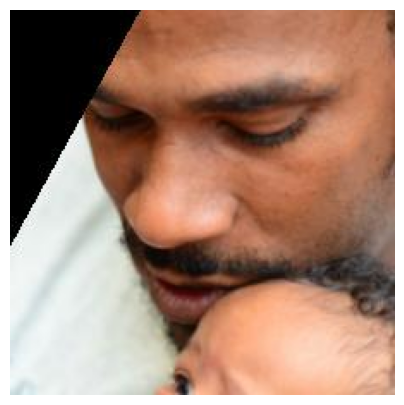

100%|██████████| 50/50 [00:05<00:00,  9.93it/s]


generated image


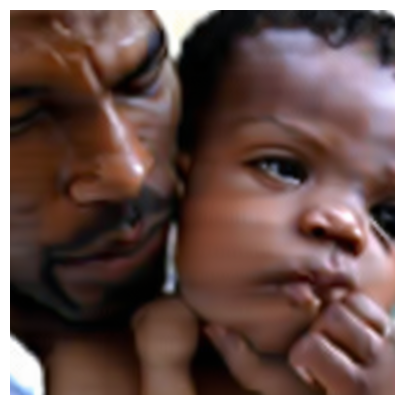

conditioning image


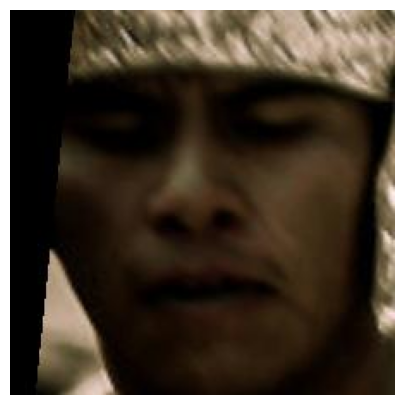

100%|██████████| 50/50 [00:05<00:00,  9.88it/s]


generated image


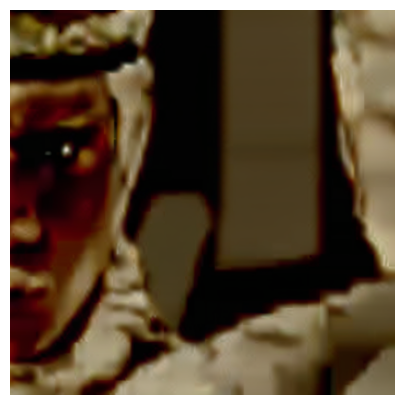

conditioning image


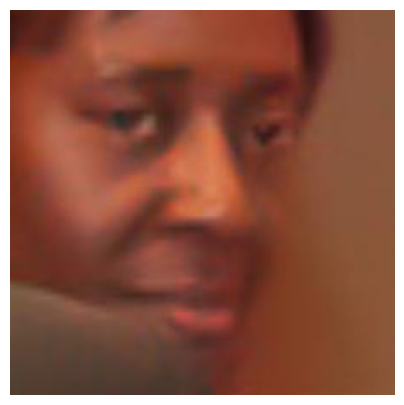

100%|██████████| 50/50 [00:05<00:00,  9.93it/s]


generated image


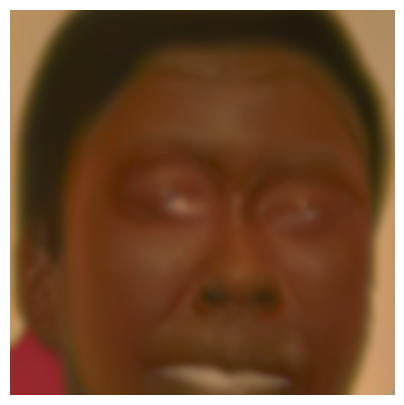

conditioning image


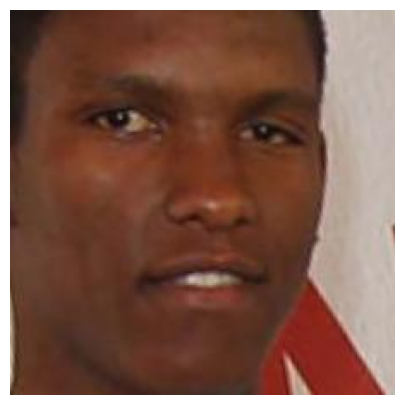

100%|██████████| 50/50 [00:05<00:00,  9.95it/s]


generated image


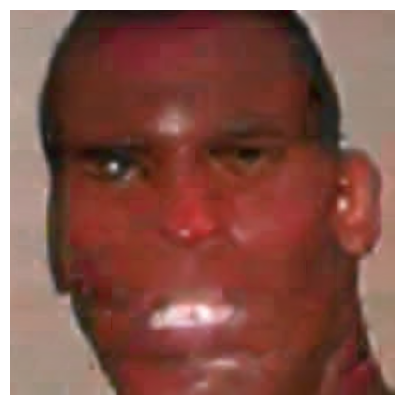

conditioning image


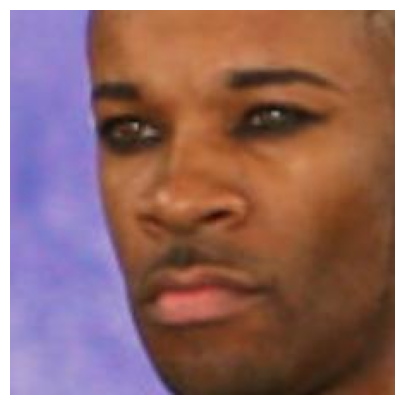

100%|██████████| 50/50 [00:05<00:00,  9.87it/s]


generated image


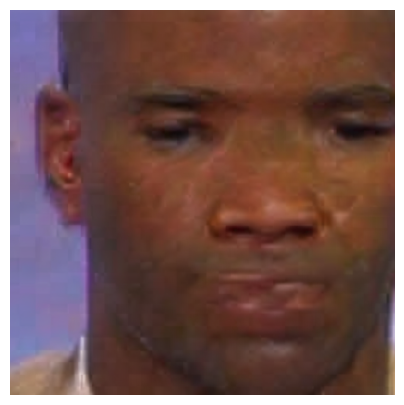

In [7]:
sample_size = 10
for i in range(sample_size):
    pipe.set_ip_adapter_scale(0.8)
    print("conditioning image")
    visualize_image(data['Black'][i])
    #low guidance scale means it should be simialr to the conditioning image
    out_image = pipe(prompt="A black person", ip_adapter_image=data['Black'][i], guidance_scale=5.5)
    print("generated image")
    visualize_image(out_image.images[0])

In [8]:
import torch
import torch.nn.functional as F

@torch.inference_mode()
def cache_activations(
    pipe,
    data_by_class,                 # {class_name: [PIL or np.ndarray, ...]}
    prompts_by_class=None,         # {class_name: "prompt ..."} (optional)
    layer_path="unet.mid_block",   # e.g. "unet.down_blocks.2.resnets.1"
    batch_size=4,
    guidance_scale=5.5,
    ip_adapter_scale=0.8,
):
    # resolve target module
    def _get_module(root, dotted):
        m = root
        for p in dotted.split('.'):
            m = getattr(m, p) if not p.isdigit() else m[int(p)]
        return m

    mod = _get_module(pipe, layer_path)
    captured = []
    hook = mod.register_forward_hook(lambda _, __, out: captured.append(out.detach()))
    pipe.set_ip_adapter_scale(ip_adapter_scale)

    activations = {k: [] for k in data_by_class}

    for cls, imgs in data_by_class.items():
        prm = (prompts_by_class.get(cls, "") if prompts_by_class else "")
        # ensure PIL
        def _to_pil(x): 
            return x if isinstance(x, Image.Image) else Image.fromarray(x)
        imgs = [ _to_pil(x) for x in imgs ]

        for i in range(0, len(imgs), batch_size):
            batch = imgs[i:i+batch_size]
            prompts = [prm] * len(batch)

            captured.clear()
            # NOTE: wrap batch per number of adapters (1 adapter -> [batch])
            _ = pipe(prompt=prompts, ip_adapter_image=[batch], guidance_scale=guidance_scale)

            A = captured[-1]                # (B, C, H, W) or (B, D)
            A = F.adaptive_avg_pool2d(A, 1).flatten(1) if A.dim()==4 else A.flatten(1) if A.dim()>2 else A
            activations[cls].append(A.float().cpu())

    hook.remove()
    return {cls: (torch.cat(v, 0).numpy() if v else torch.empty(0)) for cls, v in activations.items()}



## Let's get activations

In [14]:
data.keys()

dict_keys(['Black', 'East_Asian', 'Indian', 'Latino_Hispanic', 'Middle_Eastern', 'Southeast_Asian', 'White'])

In [ ]:
acts ={race:[] for race in data.keys()}
for race in data.keys():
    print(f"generating activations for {race} ")
    data_by_class = {race: data[race]}
    prompts_by_class = {race: f"A {race} person"}
    acts[race] = cache_activations(
        pipe,
        data_by_class=data_by_class,
        prompts_by_class=prompts_by_class,
        layer_path="unet.mid_block",   # change to any valid UNet submodule
        batch_size=8,
        guidance_scale=5.5,
        ip_adapter_scale=0.8,
    )

generating activations for Black 


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:31<00:00,  1.57it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.00 GiB. GPU 0 has a total capacity of 94.50 GiB of which 366.31 MiB is free. Including non-PyTorch memory, this process has 94.13 GiB memory in use. Of the allocated memory 66.06 GiB is allocated by PyTorch, and 27.38 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [12]:
print(acts.keys())

dict_keys(['White'])


In [13]:
input_dim = acts['Black'].shape[-1]
num_classes = len(acts)

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(a.keys())}")

# Initialize and train the classifier
classifier = K_Steering(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dim=256,
    lr=1e-3,
    device='cuda'
)

# Train on the cached activations
classifier.fit(
    activations_dict=activations_by_ethnicity,
    epochs=100,
    batch_size=4
)

print("\nClassifier trained! You can now use it for debiasing.")

KeyError: 'Black'